In [12]:
import numpy as np
import pandas as pd
import nltk
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix

In [16]:
# Download required resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [14]:
df = pd.read_csv('./data/train.csv')

In [17]:
# Drop the 'id' column if it exists
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Select a sample article and its reference summary
article = df.loc[0, 'article'] 
reference_summary = df.loc[0, 'highlights']  

# Preprocess text
stop_words = set(stopwords.words('english'))

# Tokenize sentences
sentences = sent_tokenize(article)

# Remove stopwords and special characters
def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    words = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return ' '.join(words)

processed_sentences = [preprocess_text(sentence) for sentence in sentences]

In [18]:
# Compute sentence similarity using Jaccard Similarity
def sentence_similarity(sent1, sent2):
    words1 = set(sent1.split())
    words2 = set(sent2.split())
    return len(words1 & words2) / max(len(words1 | words2), 1)  # Jaccard Similarity

# Build similarity matrix
similarity_matrix = np.zeros((len(sentences), len(sentences)))
for i in range(len(sentences)):
    for j in range(len(sentences)):
        if i != j:
            similarity_matrix[i][j] = sentence_similarity(processed_sentences[i], processed_sentences[j])


In [19]:
# Apply TextRank algorithm using NetworkX
graph = nx.from_numpy_array(similarity_matrix)
scores = nx.pagerank(graph)

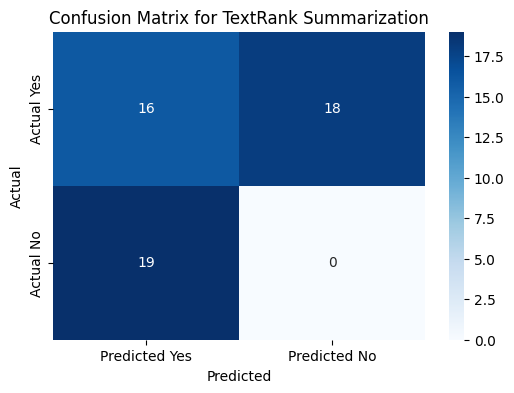


Generated Summary:
 Bishop John Folda (pictured) of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A . The bishop of the Fargo Catholic Diocese in North Dakota has exposed potentially hundreds of church members in Fargo, Grand Forks and Jamestown to the hepatitis A virus in late September and early October. Fargo Catholic Diocese in North Dakota (pictured) is where the bishop is located .

Reference Summary:
 Bishop John Folda, of North Dakota, is taking time off after being diagnosed .
He contracted the infection through contaminated food in Italy .
Church members in Fargo, Grand Forks and Jamestown could have been exposed .


In [22]:
# Rank sentences based on TextRank scores
ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

# Generate summary (top 3 ranked sentences)
top_n = 3
generated_summary = ' '.join([ranked_sentences[i][1] for i in range(min(top_n, len(ranked_sentences)))])

# Convert summaries to sets of words
reference_words = set(reference_summary.lower().split())
generated_words = set(generated_summary.lower().split())

# Calculate True Positives, False Positives, False Negatives
true_positive = len(reference_words & generated_words)
false_positive = len(generated_words - reference_words)
false_negative = len(reference_words - generated_words)

# Confusion Matrix
conf_matrix = np.array([[true_positive, false_negative], [false_positive, 0]])

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted Yes", "Predicted No"], yticklabels=["Actual Yes", "Actual No"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for TextRank Summarization")
plt.show()

# Print Summaries
print("\nGenerated Summary:\n", generated_summary)
print("\nReference Summary:\n", reference_summary)